# 导入数据

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./jd.csv')
df = df.drop_duplicates()
df.head()

,用户名,评分,评论时间,评论内容
0,j***1,5,2025-05-08 11:54:53,收到时候包装很好看，强烈推荐，用来办公和玩游戏都可以，电脑外观简约大方，屏幕非常清晰，色彩鲜...
1,啊***坨,5,2025-05-12 11:02:08,天选5的魔幻青/日蚀灰配色非常吸睛，机身轻薄便携，15.6英寸的尺寸搭配窄边框设计，屏占比高...
2,9***v,5,2025-05-17 20:00:09,包装保护：非常好，包装大气，一点都没有坏呢。外形外观：很漂亮，很开心，物流也很快很快呢。画面...
3,回***伤,5,2025-05-11 11:55:59,包装保护：完好无损外形外观：挺符合我的审美的画面品质：清晰无误运行速度：快的一匹收到就直接打...
4,M***z,5,2025-05-19 17:37:18,华硕天选五游戏性能强劲，搭载高性能处理器和显卡，运行大型游戏流畅不卡顿[^0^]。屏幕素质高...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4265 entries, 0 to 6972
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   用户名     4265 non-null   object
 1   评分      4265 non-null   int64 
 2   评论时间    4265 non-null   object
 3   评论内容    4265 non-null   object
dtypes: int64(1), object(3)
memory usage: 166.6+ KB


# 数据处理

In [3]:
df['评论时间'] = pd.to_datetime(df['评论时间'])
df['周几'] = df['评论时间'].dt.weekday
mapping = {
    0:'周一',
    1:'周二',
    2:'周三',
    3:'周四',
    4:'周五',
    5:'周六',
    6:'周日',
}
df['周几'] = df['周几'].map(mapping)

df['小时'] = df['评论时间'].dt.hour


# 情感分析

In [4]:
from snownlp import SnowNLP
import numpy as np
 
def process1(x):
    try:
        score = SnowNLP(x).sentiments
        return score
    except:
        return np.nan
     
df_ = df['评论内容'].drop_duplicates().to_frame().reset_index(drop=True)
 
df_['情感得分'] = df_['评论内容'].apply(process1)

In [5]:
df_['评分等级'] = pd.cut(df_['情感得分'],bins=[0, 0.5, 0.8, 1],labels=['差评', '中评', '好评'],right=False)  # 包含左边界，不包含右边界

# 可视化

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns

## 4.1情感得分分布直方图

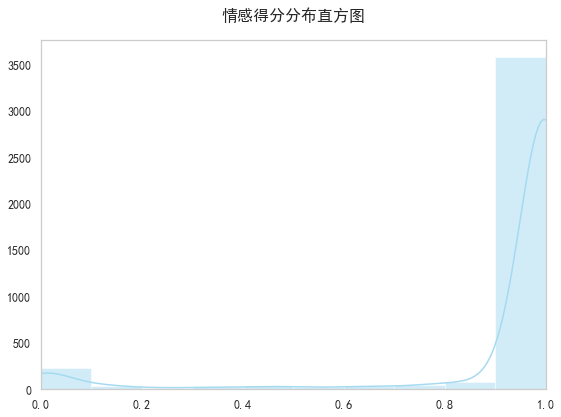

In [7]:
sns.set(style="whitegrid", font_scale=1.1,font='SimHei')

plt.figure(figsize=(8, 6))


ax = sns.histplot(
    data=df_,
    x='情感得分',
    bins=10,  # 可以调整箱数
    kde=True,  # 添加核密度估计曲线
    color='#a5daf0',
    edgecolor='white',
    linewidth=0.5
)

plt.title('情感得分分布直方图', pad=20, fontsize=16)
plt.xlabel('')
plt.ylabel('')

plt.xlim(0, 1)
plt.tight_layout()
plt.grid(False)

plt.savefig('./可视化结果/情感得分分布直方图.jpg')
plt.show()

## 4.2评分等级分布情况

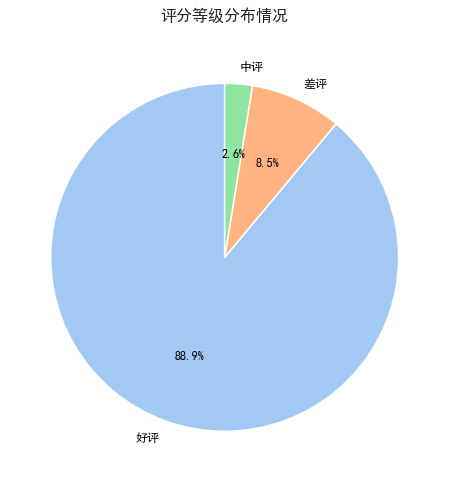

In [8]:
size_counts = df_['评分等级'].value_counts()

plt.figure(figsize=(8, 8))  # 设置画布大小


plt.pie(
    size_counts,  # 数据
    labels=size_counts.index,  # 标签
    autopct='%1.1f%%',  # 显示百分比
    startangle=90,  # 起始角度
    colors=sns.color_palette("pastel"),  # 使用 Seaborn 的 pastel 调色板
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},  # 设置扇形边缘样式
    textprops={'fontsize': 12, 'color': 'black'}  # 设置文本样式
)

plt.title("评分等级分布情况", fontsize=16, fontweight='bold', pad=20)

plt.savefig('./可视化结果/评分等级分布情况.jpg')

plt.show()

## 4.3基于星期的用户活跃度变化趋势

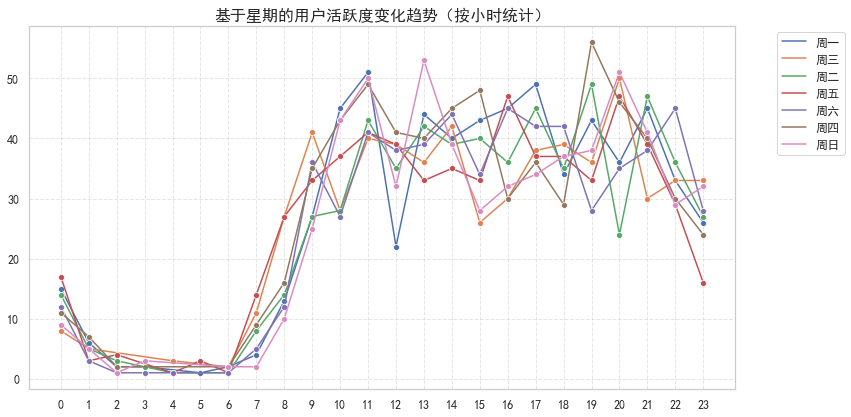

In [9]:
result = df.groupby(["周几", "小时"]).size().reset_index(name="评论数量")
plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x="小时", y="评论数量", hue="周几", marker="o")
plt.title("基于星期的用户活跃度变化趋势（按小时统计）", fontsize=16, fontweight="bold")
plt.xlabel("", fontsize=12)
plt.ylabel("", fontsize=12)
plt.xticks(range(24))  
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left") #将图例放在右侧
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()  #自动调整布局

plt.savefig('./可视化结果/基于星期的用户活跃度变化趋势.jpg')
plt.show()



## 4.4 评论词云

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lby\AppData\Local\Temp\jieba.cache
Loading model cost 0.421 seconds.
Prefix dict has been built successfully.


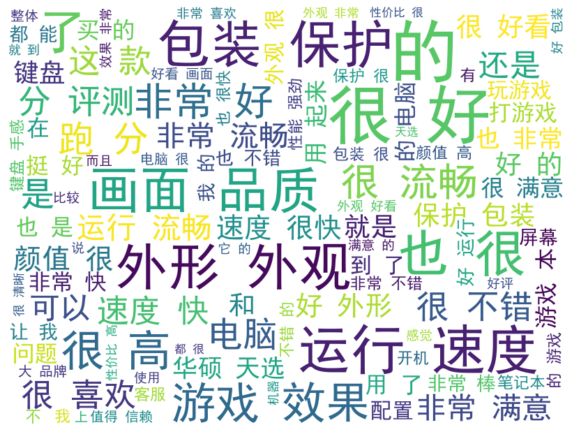

In [10]:
from wordcloud import WordCloud
import jieba


all_text = ' '.join([str(item) for item in df['评论内容'] if isinstance(item, str)])
words = jieba.lcut(all_text)
all_text = ' '.join(words)

wordcloud = WordCloud(
    font_path='simhei.ttf',  # 设置字体路径（支持中文）
    width=800,
    height=600,
    background_color='white',  # 设置背景颜色
    max_words=100,  # 设置最多显示的词数
    min_font_size=10,  # 设置最小字体大小
    max_font_size=100,  # 设置最大字体大小
    random_state=42  # 设置随机种子
).generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title('', fontsize=16)

plt.savefig('./可视化结果/评论词云.jpg')
plt.show()